<a href="https://colab.research.google.com/github/longhtt/Spotify-Hit-Song-ML-Prediction/blob/main/spotify_hit_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Spotify Hit Song Prediction
## ML Project — MLP2 & MLP3 Pipeline
**Dataset:** `from kaggle` | **Target:** Predict whether a song is a "hit" based on audio features

---
### Notebook Structure
| Section | Stage |
|---|---|
| 1. Imports & Setup | Both |
| 2. Data Loading & Preprocessing | MLP2 |
| 3. Exploratory Data Analysis | MLP2 |
| 4. Split Strategies | MLP2 |
| 5. MLP2 Baseline Models (LR + RF) | MLP2 |
| 6. MLP2 Results Summary | MLP2 |
| 7. Threshold Tuning (60 / 70 / 80) | MLP3 |
| 8. Generation-Based Splits | MLP3 |
| 9. Expanded Model Suite | MLP3 |
| 10. Hyperparameter Tuning (GridSearchCV) | MLP3 |
| 11. Final Model Comparison & Visualizations | MLP3 |

---
## Section 1 — Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, precision_recall_curve
)

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]


---
## Section 2 — Data Loading & Preprocessing
*(MLP2)*

In [ ]:
#Load Dataset
df = pd.read_csv('data/data.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (170653, 19)
Columns: ['valence', 'year', 'acousticness', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo']


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


In [ ]:
# Dataset Overview
print(f"Total records   : {len(df):,}")
print(f"Total features  : {df.shape[1]}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")

# Year range
if 'year' in df.columns:
    print(f"Year range      : {int(df['year'].min())} – {int(df['year'].max())}")

print("\nData types:")
print(df.dtypes)

Total records   : 170,653
Total features  : 19
Missing values  : 0
Duplicate rows  : 0
Year range      : 1921 – 2020

Data types:
valence             float64
year                  int64
acousticness        float64
artists              object
danceability        float64
duration_ms           int64
energy              float64
explicit              int64
id                   object
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
name                 object
popularity            int64
release_date         object
speechiness         float64
tempo               float64
dtype: object


In [ ]:
# Preprocessing

# 1. Drop duplicates & nulls (safeguard)
df = df.drop_duplicates().dropna(subset=AUDIO_FEATURES)

# 2. Target variable: binary 'hit' at threshold = 80 (MLP2 default)
df['hit_80'] = (df['popularity'] >= 80).astype(int)
df['hit_70'] = (df['popularity'] >= 70).astype(int)
df['hit_60'] = (df['popularity'] >= 60).astype(int)

print("Hit rate at threshold 80:", round(df['hit_80'].mean() * 100, 2), "%")
print("Hit rate at threshold 70:", round(df['hit_70'].mean() * 100, 2), "%")
print("Hit rate at threshold 60:", round(df['hit_60'].mean() * 100, 2), "%")

# 3. Feature matrices
X_audio = df[AUDIO_FEATURES].copy()

# With year feature
if 'year' in df.columns:
    X_audio_year = df[AUDIO_FEATURES + ['year']].copy()
else:
    X_audio_year = X_audio.copy()
    print("  'year' column not found — using audio features only.")

# 4. Scale features
scaler = StandardScaler()
X_scaled       = pd.DataFrame(scaler.fit_transform(X_audio), columns=AUDIO_FEATURES)
X_scaled_year  = pd.DataFrame(scaler.fit_transform(X_audio_year), columns=X_audio_year.columns)

print(f"\n Preprocessing complete. Feature matrix shape: {X_scaled.shape}")

Hit rate at threshold 80: 0.4 %
Hit rate at threshold 70: 2.94 %
Hit rate at threshold 60: 10.29 %

 Preprocessing complete. Feature matrix shape: (170653, 9)


---
## Section 3 — Exploratory Data Analysis
*(MLP2)*

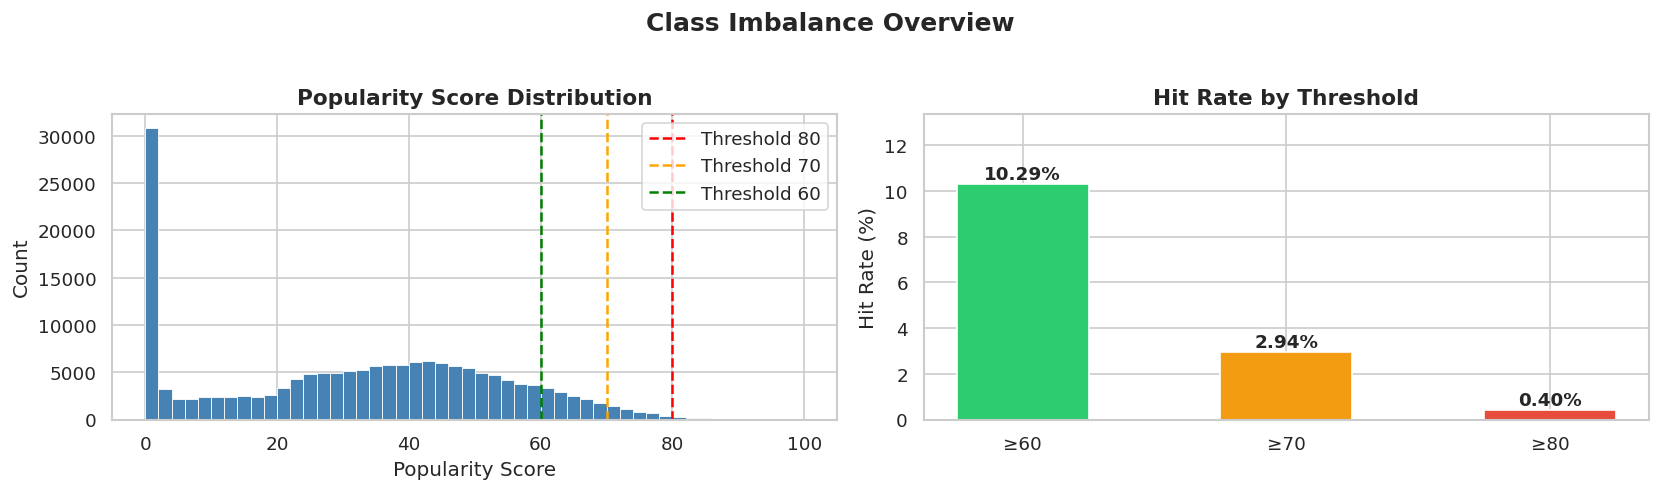

In [ ]:
# ── 3.1 Popularity Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(80, color='red',    linestyle='--', linewidth=1.5, label='Threshold 80')
axes[0].axvline(70, color='orange', linestyle='--', linewidth=1.5, label='Threshold 70')
axes[0].axvline(60, color='green',  linestyle='--', linewidth=1.5, label='Threshold 60')
axes[0].set_title('Popularity Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class imbalance bar chart
thresholds = [60, 70, 80]
hit_rates = [df[f'hit_{t}'].mean() * 100 for t in thresholds]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar([f'≥{t}' for t in thresholds], hit_rates, color=colors, edgecolor='white', width=0.5)
for bar, rate in zip(bars, hit_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{rate:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Hit Rate by Threshold', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Hit Rate (%)')
axes[1].set_ylim(0, max(hit_rates) * 1.3)

plt.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

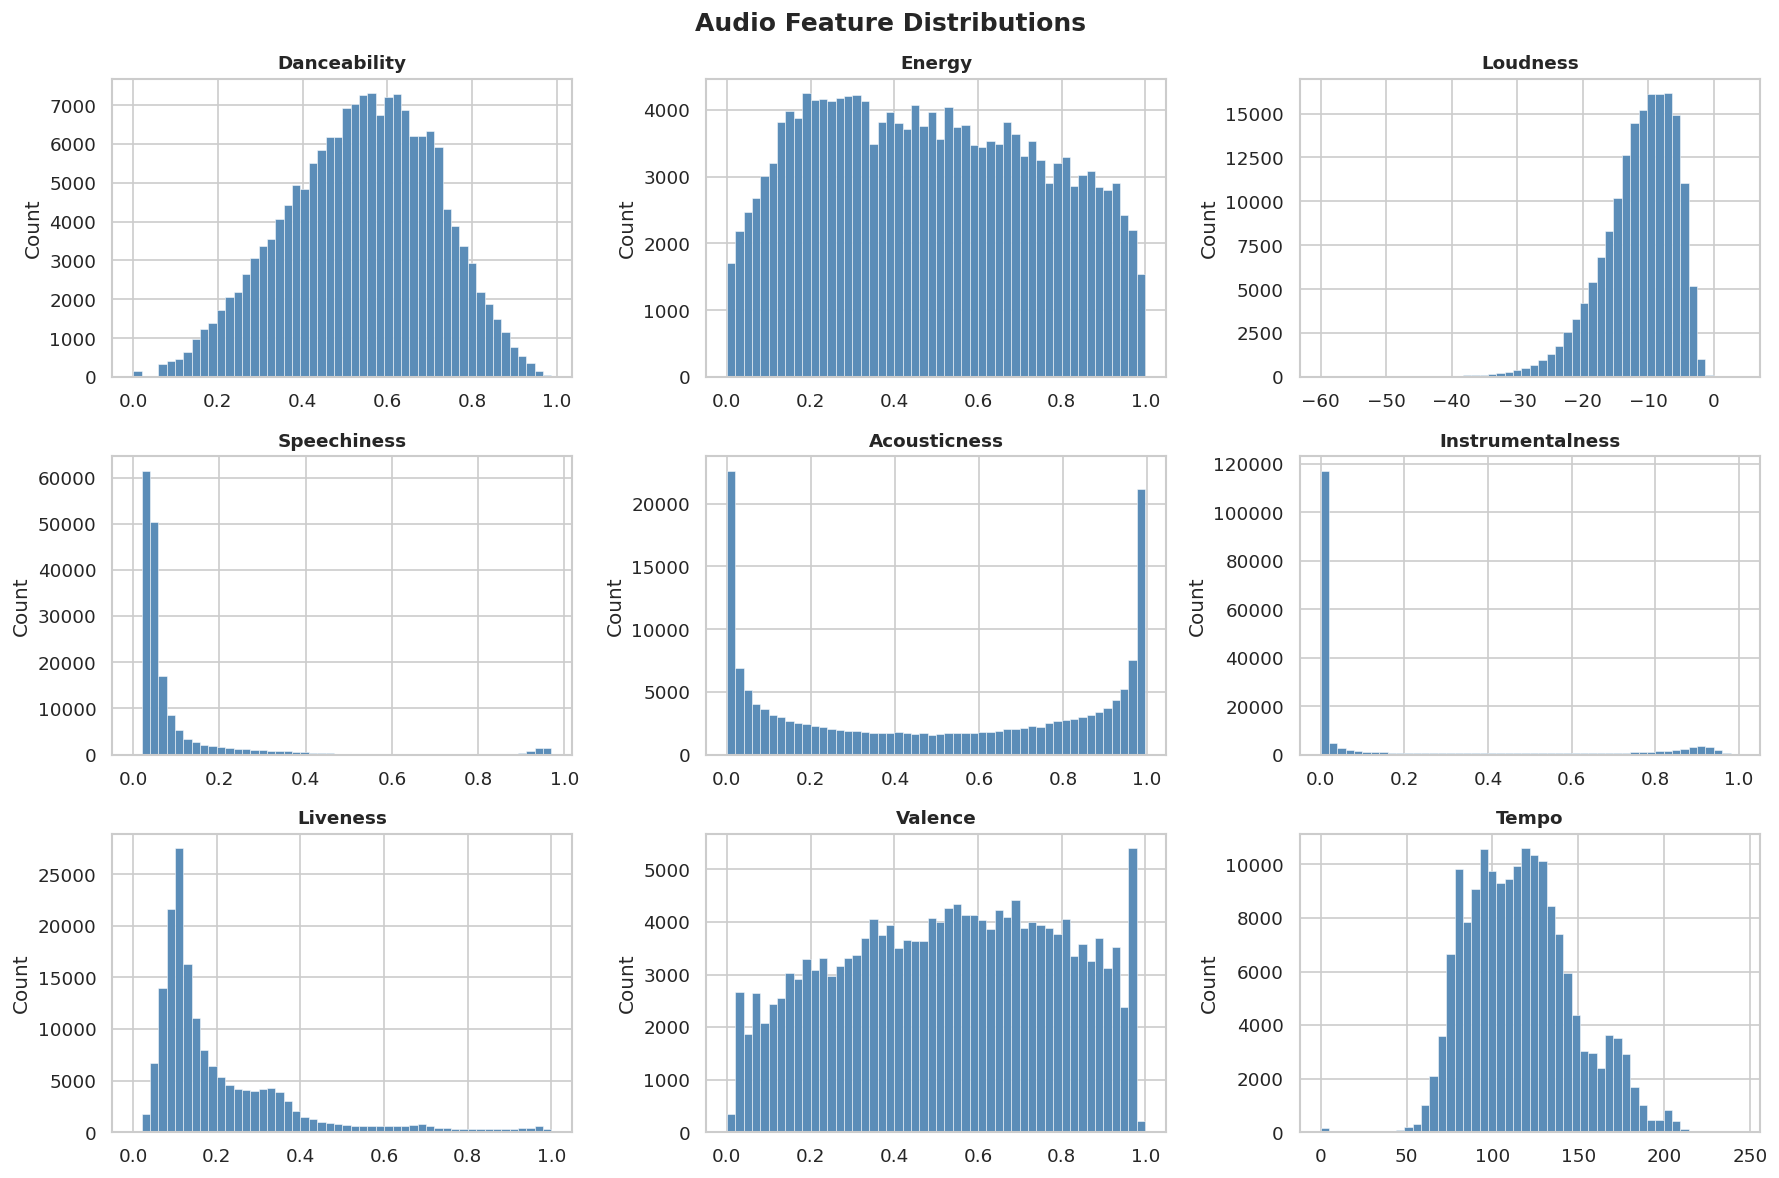

In [ ]:
# ── 3.2 Audio Feature Distributions ───────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feature], bins=50, color='#5B8DB8', edgecolor='white', linewidth=0.3)
    axes[i].set_title(feature.capitalize(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Audio Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

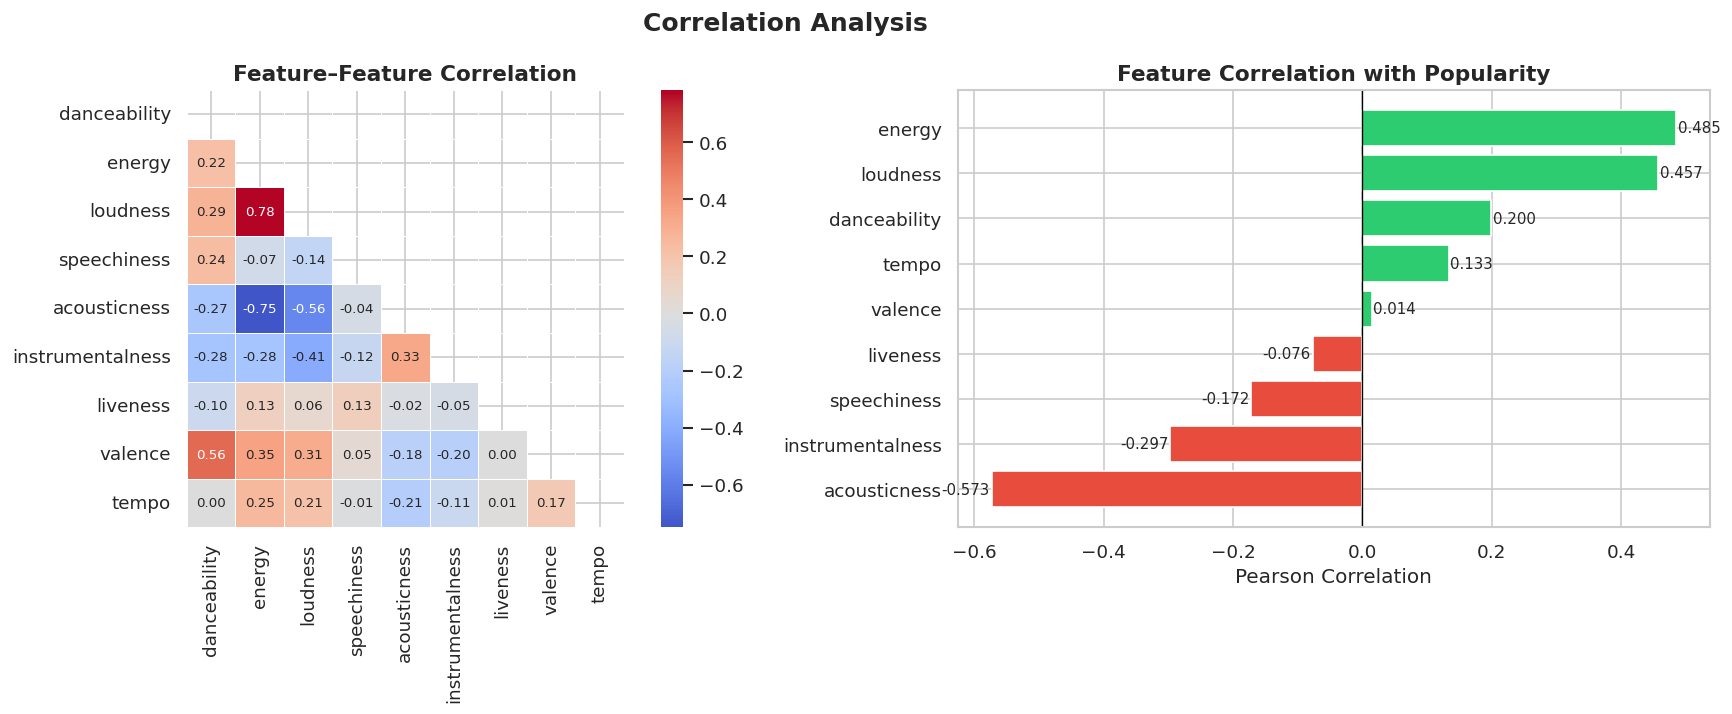

In [ ]:
# ── 3.3 Correlation Heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature-to-feature correlation
corr_matrix = df[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
axes[0].set_title('Feature–Feature Correlation', fontsize=13, fontweight='bold')

# Feature correlation with popularity
pop_corr = df[AUDIO_FEATURES].corrwith(df['popularity']).sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in pop_corr]
axes[1].barh(pop_corr.index, pop_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Popularity', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
for i, (val, name) in enumerate(zip(pop_corr.values, pop_corr.index)):
    axes[1].text(val + (0.003 if val >= 0 else -0.003), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Correlation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

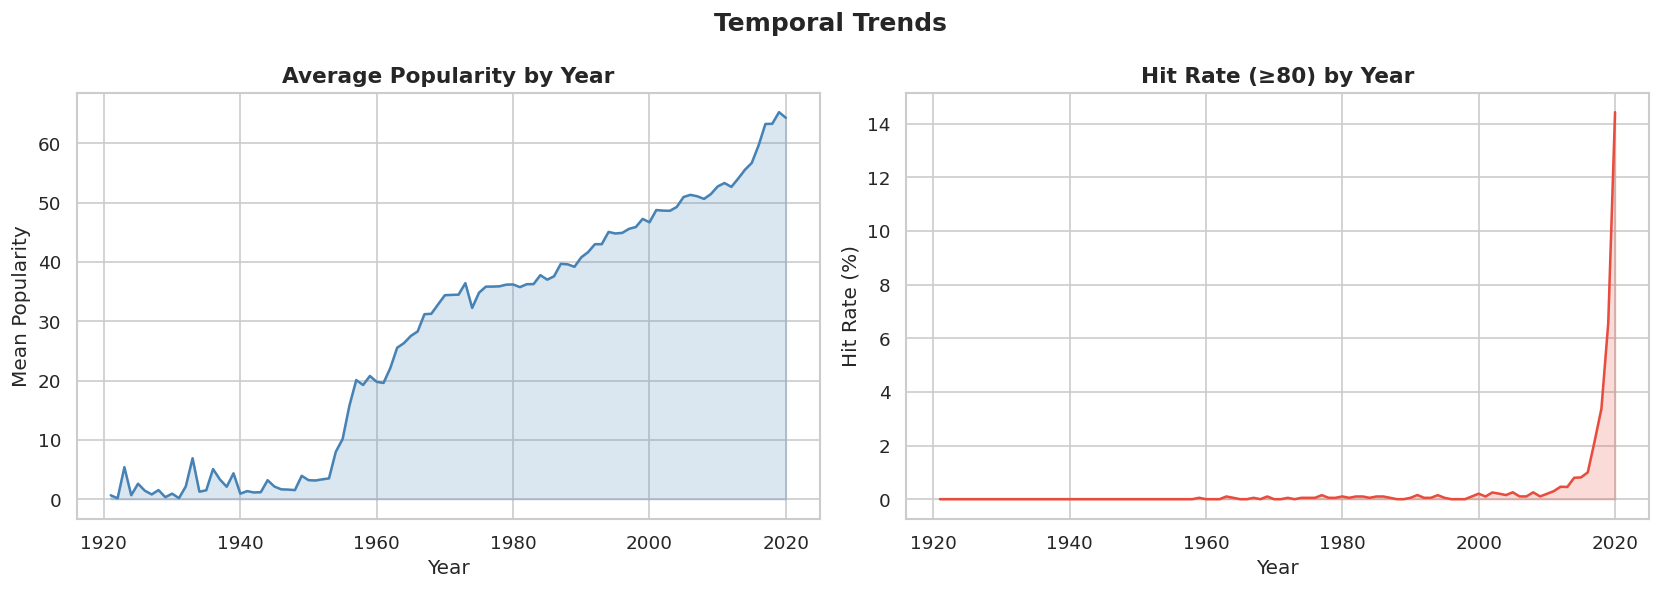

In [ ]:
# ── 3.4 Temporal Trends ────────────────────────────────────────────────────────
if 'year' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    yearly = df.groupby('year')['popularity'].mean()
    axes[0].plot(yearly.index, yearly.values, color='steelblue', linewidth=1.5)
    axes[0].fill_between(yearly.index, yearly.values, alpha=0.2, color='steelblue')
    axes[0].set_title('Average Popularity by Year', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Mean Popularity')

    hit_by_year = df.groupby('year')['hit_80'].mean() * 100
    axes[1].plot(hit_by_year.index, hit_by_year.values, color='#e74c3c', linewidth=1.5)
    axes[1].fill_between(hit_by_year.index, hit_by_year.values, alpha=0.2, color='#e74c3c')
    axes[1].set_title('Hit Rate (≥80) by Year', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Hit Rate (%)')

    plt.suptitle('Temporal Trends', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("  No 'year' column found — skipping temporal plot.")

---
## Section 4 — Split Strategies
*(MLP2)*

Three strategies are evaluated:
- **Random stratified 80/20**
- **Temporal split** — train on pre-2018, test on post-2018
- **Era split** — train on pre-2015, test on post-2015

In [ ]:
# ── Helper: build splits ───────────────────────────────────────────────────────
def make_splits(X, y, df_ref, include_year=False):
    """Returns dict of {split_name: (X_train, X_test, y_train, y_test)}."""
    splits = {}

    # 1. Random stratified
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    splits['Random (80/20)'] = (X_tr, X_te, y_tr, y_te)

    # 2. Temporal split — 2018
    if 'year' in df_ref.columns:
        mask_train = df_ref['year'] < 2018
        mask_test  = df_ref['year'] >= 2018
        if mask_train.sum() > 0 and mask_test.sum() > 0:
            splits['Temporal (<2018)'] = (
                X[mask_train], X[mask_test], y[mask_train], y[mask_test])

    # 3. Era split — 2015
    if 'year' in df_ref.columns:
        mask_train = df_ref['year'] < 2015
        mask_test  = df_ref['year'] >= 2015
        if mask_train.sum() > 0 and mask_test.sum() > 0:
            splits['Era (<2015)'] = (
                X[mask_train], X[mask_test], y[mask_train], y[mask_test])

    # Print split sizes
    for name, (Xtr, Xte, ytr, yte) in splits.items():
        print(f"{name:22s} | Train: {len(ytr):6,}  Test: {len(yte):6,} | "
              f"Train hit%: {ytr.mean()*100:.2f}  Test hit%: {yte.mean()*100:.2f}")
    return splits

y_80 = df['hit_80'].values
X_np = X_scaled.values  # no-year version

print("=== Splits for threshold=80 (no year feature) ===")
splits_80 = make_splits(X_np, y_80, df)

=== Splits for threshold=80 (no year feature) ===
Random (80/20)         | Train: 136,522  Test: 34,131 | Train hit%: 0.40  Test hit%: 0.40
Temporal (<2018)       | Train: 164,571  Test:  6,082 | Train hit%: 0.12  Test hit%: 8.09
Era (<2015)            | Train: 158,808  Test: 11,845 | Train hit%: 0.07  Test hit%: 4.80


---
## Section 5 — MLP2 Baseline Models
*(Logistic Regression & Random Forest)*

In [ ]:
# ── Evaluation helper ──────────────────────────────────────────────────────────
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan
    return {
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 3),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 3),
        'ROC-AUC':   round(auc, 3)
    }

# ── Running MLP2 experiments ────────────────────────────────────────────────────────
mlp2_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
}

mlp2_results = []
for split_name, (Xtr, Xte, ytr, yte) in splits_80.items():
    for model_name, model in mlp2_models.items():
        metrics = evaluate_model(model, Xtr, Xte, ytr, yte)
        row = {'Split': split_name, 'Model': model_name, **metrics}
        mlp2_results.append(row)
        print(f"{split_name:22s} | {model_name:22s} | "
              f"P={metrics['Precision']:.3f} R={metrics['Recall']:.3f} "
              f"F1={metrics['F1-Score']:.3f} AUC={metrics['ROC-AUC']:.3f}")

Random (80/20)         | Logistic Regression    | P=0.016 R=0.891 F1=0.031 AUC=0.897
Random (80/20)         | Random Forest          | P=0.182 R=0.029 F1=0.050 AUC=0.820
Temporal (<2018)       | Logistic Regression    | P=0.089 R=0.917 F1=0.162 AUC=0.595
Temporal (<2018)       | Random Forest          | P=0.000 R=0.000 F1=0.000 AUC=0.579
Era (<2015)            | Logistic Regression    | P=0.057 R=0.865 F1=0.106 AUC=0.618
Era (<2015)            | Random Forest          | P=0.000 R=0.000 F1=0.000 AUC=0.553


---
## Section 6 — MLP2 Results Summary

In [ ]:
# ── Results table ──────────────────────────────────────────────────────────────
mlp2_df = pd.DataFrame(mlp2_results)

# Style the table
styled = (mlp2_df.style
    .format({'Precision': '{:.3f}', 'Recall': '{:.3f}',
             'F1-Score': '{:.3f}', 'ROC-AUC': '{:.3f}'})
    .background_gradient(subset=['F1-Score', 'ROC-AUC'], cmap='RdYlGn')
    .set_caption('MLP2 Baseline Results — Threshold=80')
    .set_properties(**{'text-align': 'center'})
)
styled

,Split,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random (80/20),Logistic Regression,0.016,0.891,0.031,0.897
1,Random (80/20),Random Forest,0.182,0.029,0.050,0.820
2,Temporal (<2018),Logistic Regression,0.089,0.917,0.162,0.595
3,Temporal (<2018),Random Forest,0.000,0.000,0.000,0.579
4,Era (<2015),Logistic Regression,0.057,0.865,0.106,0.618
5,Era (<2015),Random Forest,0.000,0.000,0.000,0.553


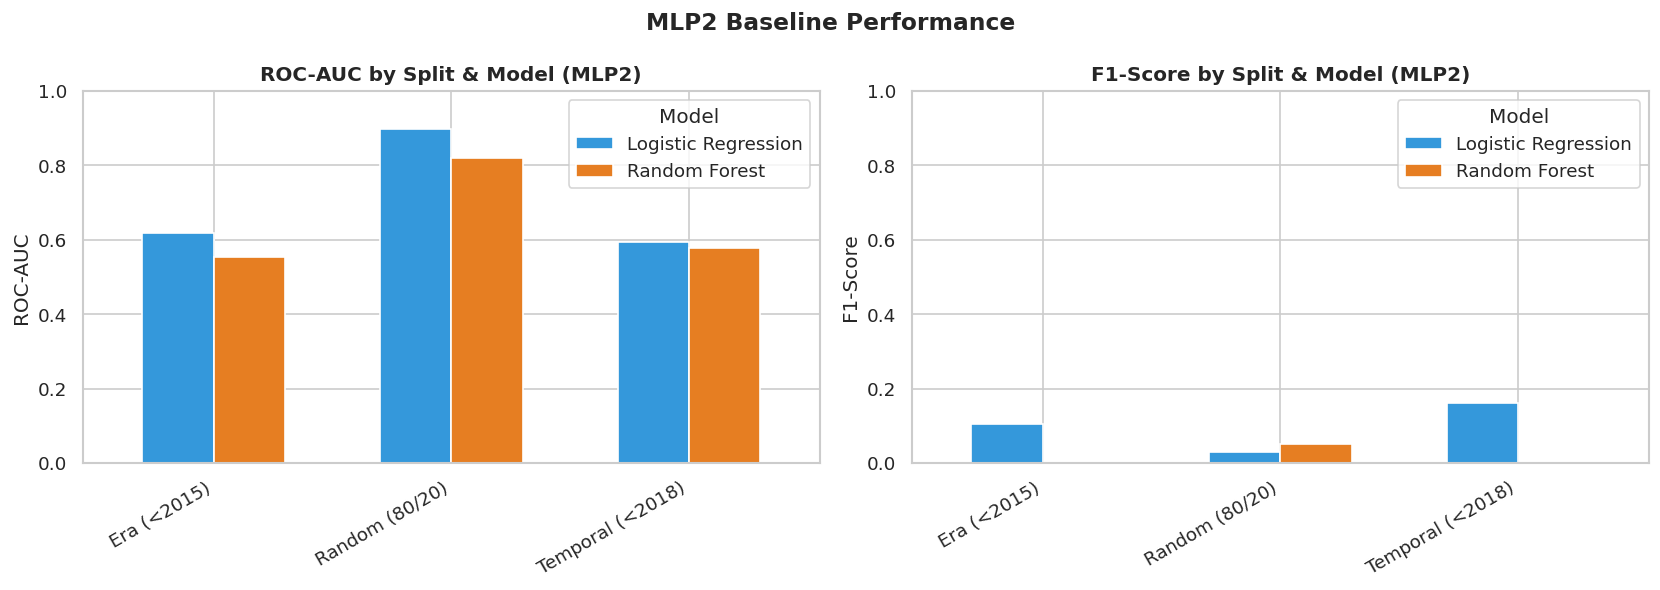

In [ ]:
# ── ROC-AUC comparison bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['ROC-AUC', 'F1-Score']):
    pivot = mlp2_df.pivot(index='Split', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'],
               edgecolor='white', width=0.6)
    ax.set_title(f'{metric} by Split & Model (MLP2)', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Model')
    ax.set_ylim(0, 1)

plt.suptitle('MLP2 Baseline Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**MLP2 Key Findings**

1. Random stratified splits yield high ROC-AUC (~0.82–0.90) but near-zero F1-scores,
   indicating the model discriminates but cannot produce useful minority-class predictions.

2. Logistic Regression consistently outperforms Random Forest on temporal splits in recall.
   RF collapses to zero recall on temporal splits (predicts all non-hits).

3. Large ROC-AUC gap (random ~0.90 vs temporal ~0.55–0.62) confirms temporal distribution
   shift. Spotify popularity is recency-weighted, so random splits introduce evaluation bias.

4. Audio features alone have weak predictive power across time — suggesting non-linear or
   time-aware modeling is needed.

→ MLP3 addresses these via: threshold relaxation, generation-based splits,
  additional models, and hyperparameter tuning.

---
## Section 7 — Threshold Tuning (60 / 70 / 80)
*(MLP3)*

Relaxing the 'hit' threshold reduces class imbalance and makes the classification problem more learnable. We evaluate all three thresholds under the same random stratified split with Logistic Regression and Random Forest.

In [ ]:
# ── Threshold sweep ────────────────────────────────────────────────────────────
threshold_results = []

for thresh in [80, 70, 60]:
    y_t = df[f'hit_{thresh}'].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_np, y_t, test_size=0.2, stratify=y_t, random_state=RANDOM_STATE)

    for model_name, model in {
        'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
    }.items():
        metrics = evaluate_model(model, X_tr, X_te, y_tr, y_te)
        threshold_results.append({'Threshold': f'≥{thresh}', 'Model': model_name,
                                   'Hit Rate %': round(y_t.mean()*100, 2), **metrics})

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

Threshold               Model  Hit Rate %  Precision  Recall  F1-Score  ROC-AUC
      ≥80 Logistic Regression        0.40      0.016   0.891     0.031    0.897
      ≥80       Random Forest        0.40      0.182   0.029     0.050    0.820
      ≥70 Logistic Regression        2.94      0.084   0.809     0.153    0.838
      ≥70       Random Forest        2.94      0.325   0.037     0.066    0.839
      ≥60 Logistic Regression       10.29      0.234   0.788     0.361    0.807
      ≥60       Random Forest       10.29      0.555   0.146     0.231    0.839


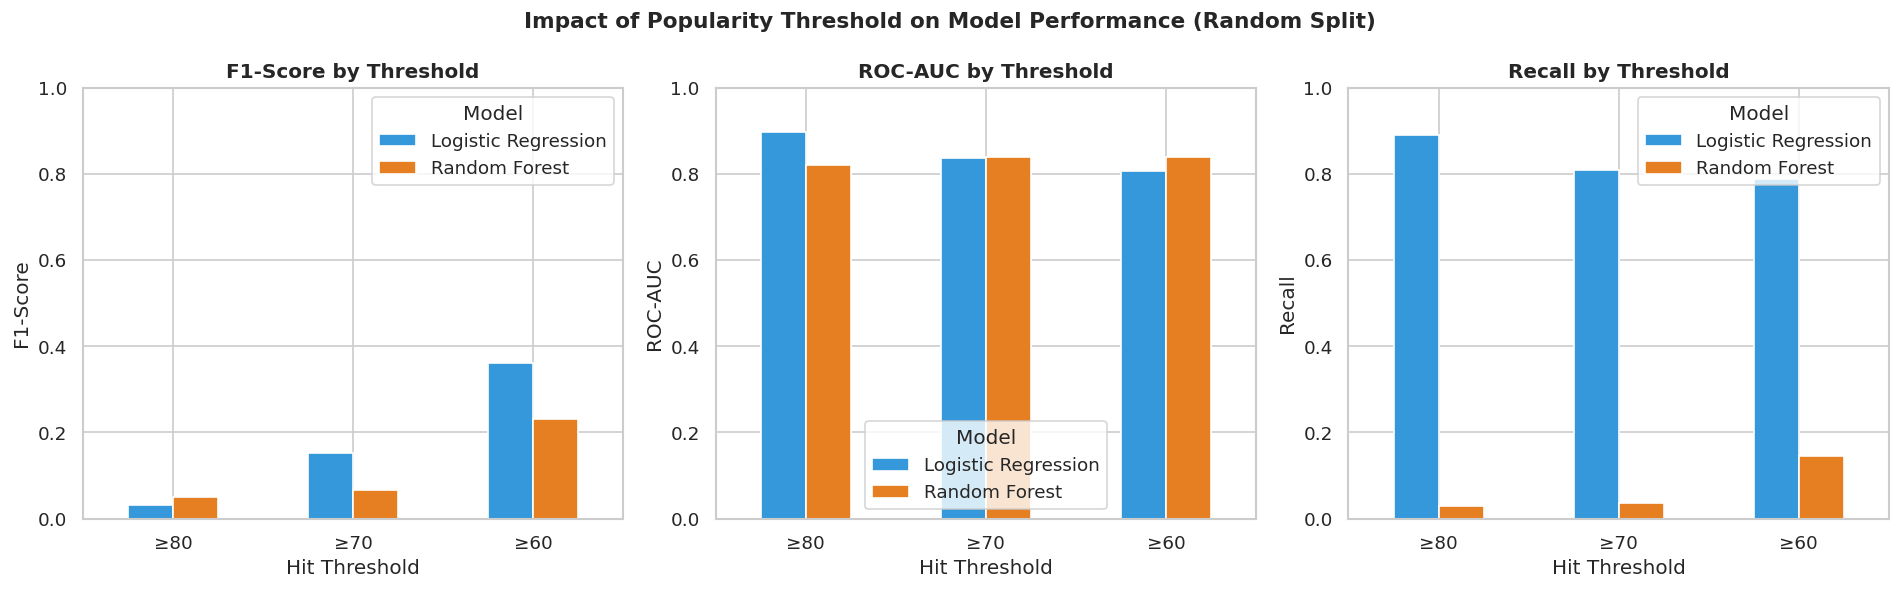

In [ ]:
# ── Threshold comparison plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['F1-Score', 'ROC-AUC', 'Recall']):
    pivot = thresh_df.pivot(index='Threshold', columns='Model', values=metric)
    pivot = pivot.reindex([f'≥{t}' for t in [80, 70, 60]])
    pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'],
               edgecolor='white', width=0.5)
    ax.set_title(f'{metric} by Threshold', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hit Threshold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Model')
    ax.set_ylim(0, 1)

plt.suptitle('Impact of Popularity Threshold on Model Performance (Random Split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Threshold decision ─────────────────────────────────────────────────────────
# Compute best threshold per metric
for metric in ['F1-Score', 'ROC-AUC']:
    best = thresh_df.loc[thresh_df[metric].idxmax()]
    print(f"Best {metric:10s}: threshold={best['Threshold']}, model={best['Model']}, value={best[metric]:.3f}")

print("""
Recommendation: Threshold ≥ 60 is recommended for MLP3.
- Higher hit rate reduces class imbalance → better precision-recall balance
- Reframes task as 'commercially viable song' vs 'obscure song'
- Improves learnability for all model types
""")

Best F1-Score  : threshold=≥60, model=Logistic Regression, value=0.361
Best ROC-AUC   : threshold=≥80, model=Logistic Regression, value=0.897

Recommendation: Threshold ≥ 60 is recommended for MLP3.
- Higher hit rate reduces class imbalance → better precision-recall balance
- Reframes task as 'commercially viable song' vs 'obscure song'
- Improves learnability for all model types



---
## Section 8 — Generation-Based Splits
*(MLP3)*

Rather than arbitrary year cutoffs, we group music by cultural generation. Training and testing within generations reduces temporal covariate shift while preserving meaningful musical eras.

| Generation | Birth Years | Music Era |
|---|---|---|
| Silent / Boomer | 1921–1964 | Pre-rock to Classic Rock |
| Gen X | 1965–1980 | MTV era, Grunge, Hip-Hop origins |
| Millennial | 1981–1996 | Pop, R&B, early streaming |
| Gen Z | 1997–2012 | Streaming-native, TikTok era |
| Gen Alpha | 2013–present | Post-pandemic pop |

In [ ]:
# ── Assign generations ─────────────────────────────────────────────────────────
if 'year' not in df.columns:
    print(" No 'year' column — skipping generation splits.")
else:
    def assign_generation(year):
        if year < 1965:   return 'Boomer/Silent'
        elif year < 1981: return 'Gen X'
        elif year < 1997: return 'Millennial'
        elif year < 2013: return 'Gen Z'
        else:             return 'Gen Alpha'

    df['generation'] = df['year'].apply(assign_generation)
    gen_order = ['Boomer/Silent', 'Gen X', 'Millennial', 'Gen Z', 'Gen Alpha']

    print("=== Generation Distribution ===")
    gen_stats = df.groupby('generation').agg(
        Count=('popularity', 'count'),
        Avg_Popularity=('popularity', 'mean'),
        Hit_Rate_80=('hit_80', 'mean'),
        Hit_Rate_60=('hit_60', 'mean')
    ).reindex(gen_order)
    gen_stats['Hit_Rate_80'] = (gen_stats['Hit_Rate_80'] * 100).round(2)
    gen_stats['Hit_Rate_60'] = (gen_stats['Hit_Rate_60'] * 100).round(2)
    gen_stats['Count'] = gen_stats['Count'].astype(int)
    print(gen_stats.to_string())

=== Generation Distribution ===
               Count  Avg_Popularity  Hit_Rate_80  Hit_Rate_60
generation                                                    
Boomer/Silent  59503        8.239501         0.01         0.34
Gen X          31899       33.621838         0.04         3.67
Millennial     31850       40.142951         0.07         5.49
Gen Z          31575       49.674553         0.17        14.83
Gen Alpha      15826       60.288449         3.75        61.59


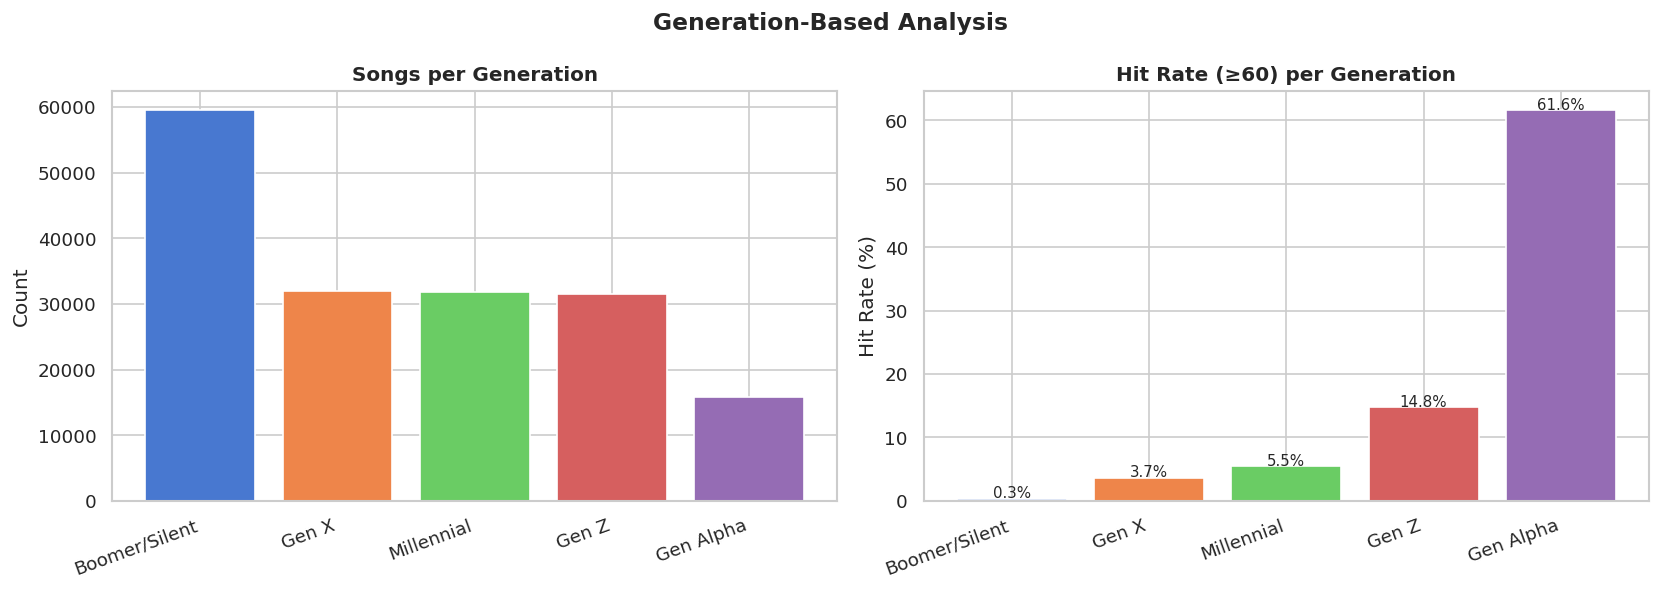

In [ ]:
# ── Generation distribution plot ────────────────────────────────────────────────
if 'generation' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    gen_counts = df['generation'].value_counts().reindex(gen_order)

    axes[0].bar(gen_counts.index, gen_counts.values,
                color=sns.color_palette('muted', len(gen_order)), edgecolor='white')
    axes[0].set_title('Songs per Generation', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(gen_counts.index, rotation=20, ha='right')

    gen_hit = df.groupby('generation')['hit_60'].mean().reindex(gen_order) * 100
    axes[1].bar(gen_hit.index, gen_hit.values,
                color=sns.color_palette('muted', len(gen_order)), edgecolor='white')
    axes[1].set_title('Hit Rate (≥60) per Generation', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Hit Rate (%)')
    axes[1].set_xticklabels(gen_hit.index, rotation=20, ha='right')
    for i, v in enumerate(gen_hit.values):
        if not np.isnan(v):
            axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

    plt.suptitle('Generation-Based Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Generation-based train/test split ──────────────────────────────────────────
# Strategy: Train on Millennial era, Test on Gen Z era (most realistic forward-prediction)
gen_results = []

if 'generation' in df.columns:
    gen_pairs = [
        ('Gen X → Millennial',   'Gen X',       'Millennial'),
        ('Millennial → Gen Z',   'Millennial',  'Gen Z'),
        ('Gen Z → Gen Alpha',    'Gen Z',        'Gen Alpha'),
    ]

    y_60 = df['hit_60'].values
    scaler2 = StandardScaler()
    X_np2 = scaler2.fit_transform(X_audio)

    for split_name, train_gen, test_gen in gen_pairs:
        train_mask = df['generation'] == train_gen
        test_mask  = df['generation'] == test_gen

        if train_mask.sum() < 100 or test_mask.sum() < 100:
            print(f"   Skipping {split_name} — insufficient data")
            continue

        X_tr, X_te = X_np2[train_mask], X_np2[test_mask]
        y_tr, y_te = y_60[train_mask], y_60[test_mask]

        for model_name, model in {
            'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
            'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
        }.items():
            metrics = evaluate_model(model, X_tr, X_te, y_tr, y_te)
            gen_results.append({'Split': split_name, 'Model': model_name,
                                 'Train': train_gen, 'Test': test_gen,
                                 'Train N': int(train_mask.sum()),
                                 'Test N': int(test_mask.sum()), **metrics})
            print(f"{split_name:28s} | {model_name:22s} | "
                  f"P={metrics['Precision']:.3f} R={metrics['Recall']:.3f} "
                  f"F1={metrics['F1-Score']:.3f} AUC={metrics['ROC-AUC']:.3f}")

    if gen_results:
        gen_df = pd.DataFrame(gen_results)
        display(gen_df[['Split','Model','F1-Score','ROC-AUC','Recall','Precision']].style
                .background_gradient(subset=['F1-Score','ROC-AUC'], cmap='RdYlGn')
                .set_caption('Generation-Based Split Results — Threshold=60'))
else:
    print("Generation column not available.")

Gen X → Millennial           | Logistic Regression    | P=0.072 R=0.818 F1=0.132 AUC=0.654
Gen X → Millennial           | Random Forest          | P=0.043 R=0.001 F1=0.001 AUC=0.596
Millennial → Gen Z           | Logistic Regression    | P=0.171 R=0.835 F1=0.285 AUC=0.614
Millennial → Gen Z           | Random Forest          | P=0.310 R=0.002 F1=0.004 AUC=0.583
Gen Z → Gen Alpha            | Logistic Regression    | P=0.652 R=0.683 F1=0.667 AUC=0.569
Gen Z → Gen Alpha            | Random Forest          | P=0.500 R=0.001 F1=0.002 AUC=0.548


,Split,Model,F1-Score,ROC-AUC,Recall,Precision
0,Gen X → Millennial,Logistic Regression,0.132000,0.654000,0.818000,0.072000
1,Gen X → Millennial,Random Forest,0.001000,0.596000,0.001000,0.043000
2,Millennial → Gen Z,Logistic Regression,0.285000,0.614000,0.835000,0.171000
3,Millennial → Gen Z,Random Forest,0.004000,0.583000,0.002000,0.310000
4,Gen Z → Gen Alpha,Logistic Regression,0.667000,0.569000,0.683000,0.652000
5,Gen Z → Gen Alpha,Random Forest,0.002000,0.548000,0.001000,0.500000


---
## Section 9 — Expanded Model Suite
*(MLP3)*

All models evaluated under identical conditions: threshold=60, random stratified 80/20 split, StandardScaler, `class_weight='balanced'` where supported.

In [ ]:
# ── Define all MLP3 models ─────────────────────────────────────────────────────
mlp3_models = {
    'Logistic Regression':     LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest':           RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree':           DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=RANDOM_STATE),
    'KNN':                     KNeighborsClassifier(n_neighbors=15, weights='distance'),
    'SGD Classifier':          SGDClassifier(class_weight='balanced', loss='modified_huber', max_iter=1000, random_state=RANDOM_STATE),
    'Gradient Boosting':       GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE),
}

# ── Prepare data for threshold=60 ──────────────────────────────────────────────
y_60  = df['hit_60'].values
X_tr60, X_te60, y_tr60, y_te60 = train_test_split(
    X_np, y_60, test_size=0.2, stratify=y_60, random_state=RANDOM_STATE)

print(f"Train size: {len(y_tr60):,}  |  Test size: {len(y_te60):,}")
print(f"Train hit rate: {y_tr60.mean()*100:.2f}%  |  Test hit rate: {y_te60.mean()*100:.2f}%")

Train size: 136,522  |  Test size: 34,131
Train hit rate: 10.29%  |  Test hit rate: 10.28%


In [ ]:
# ── Train & evaluate all models ────────────────────────────────────────────────
mlp3_results = []

for model_name, model in mlp3_models.items():
    print(f"Training {model_name}...", end=' ')
    metrics = evaluate_model(model, X_tr60, X_te60, y_tr60, y_te60)
    mlp3_results.append({'Model': model_name, **metrics})
    print(f"F1={metrics['F1-Score']:.3f}  AUC={metrics['ROC-AUC']:.3f}")

mlp3_df = pd.DataFrame(mlp3_results).sort_values('F1-Score', ascending=False)
print("\n=== Ranked by F1-Score ===")
print(mlp3_df.to_string(index=False))

Training Logistic Regression... F1=0.361  AUC=0.807
Training Random Forest... F1=0.231  AUC=0.839
Training Decision Tree... F1=0.378  AUC=0.817
Training KNN... F1=0.235  AUC=0.794
Training SGD Classifier... F1=0.362  AUC=0.807
Training Gradient Boosting... F1=0.211  AUC=0.844

=== Ranked by F1-Score ===
              Model  Precision  Recall  F1-Score  ROC-AUC
      Decision Tree      0.252   0.757     0.378    0.817
     SGD Classifier      0.237   0.770     0.362    0.807
Logistic Regression      0.234   0.788     0.361    0.807
                KNN      0.499   0.154     0.235    0.794
      Random Forest      0.555   0.146     0.231    0.839
  Gradient Boosting      0.602   0.128     0.211    0.844


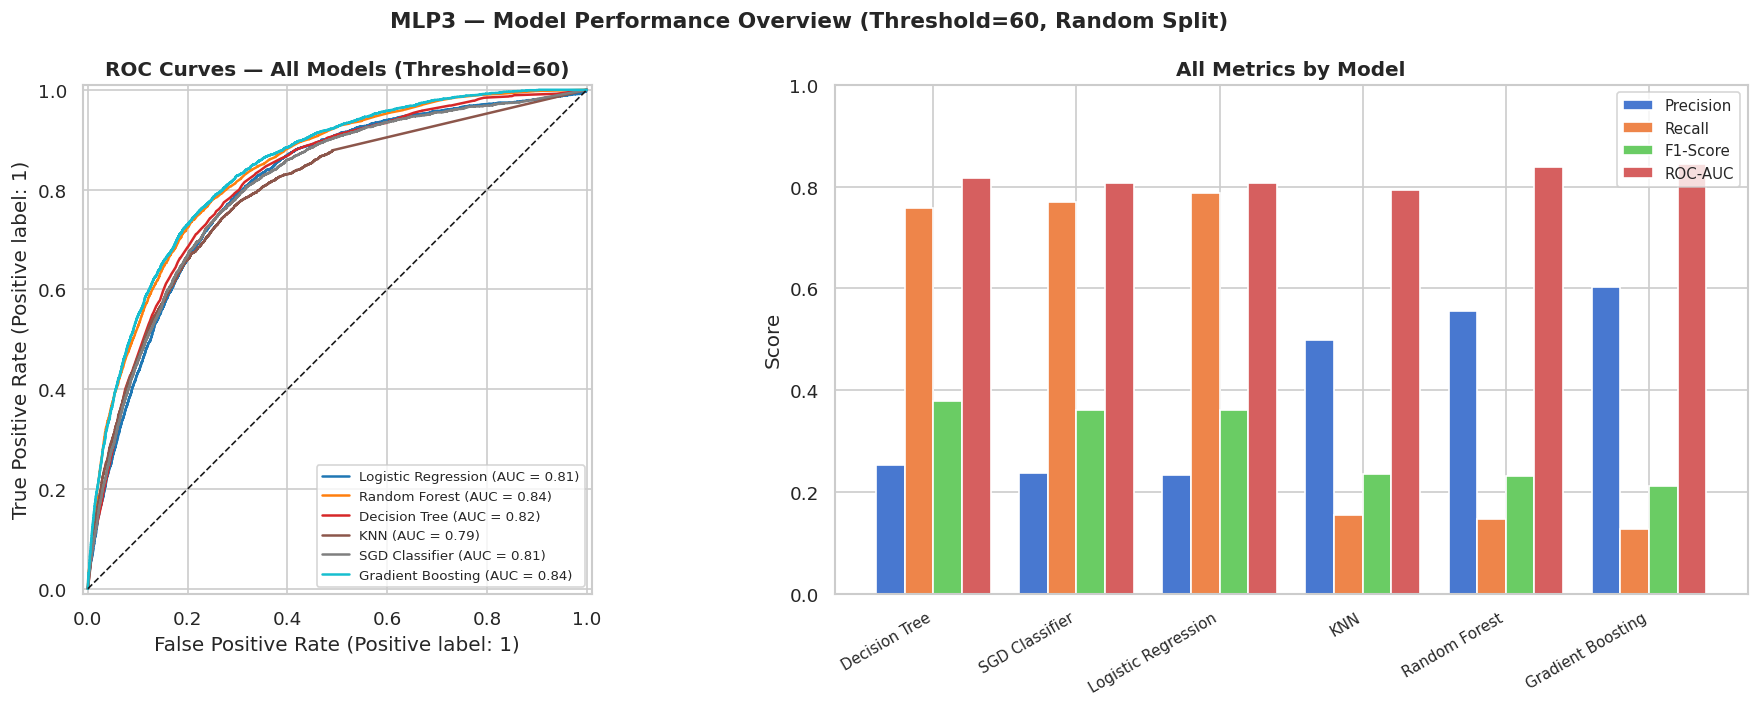

In [ ]:
# ── ROC curves for all models ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 0.9, len(mlp3_models)))

# ROC Curves
for (model_name, model), color in zip(mlp3_models.items(), colors):
    model.fit(X_tr60, y_tr60)
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_te60)[:, 1]
        else:
            y_prob = model.decision_function(X_te60)
        RocCurveDisplay.from_predictions(y_te60, y_prob, ax=axes[0],
                                          name=model_name, color=color, lw=1.5)
    except Exception as e:
        print(f"Could not plot ROC for {model_name}: {e}")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curves — All Models (Threshold=60)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)

# Performance bar chart
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(mlp3_df))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    axes[1].bar(x + i * width, mlp3_df[metric], width, label=metric,
                color=sns.color_palette('muted')[i], edgecolor='white')

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(mlp3_df['Model'], rotation=30, ha='right', fontsize=9)
axes[1].set_title('All Metrics by Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

plt.suptitle('MLP3 — Model Performance Overview (Threshold=60, Random Split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

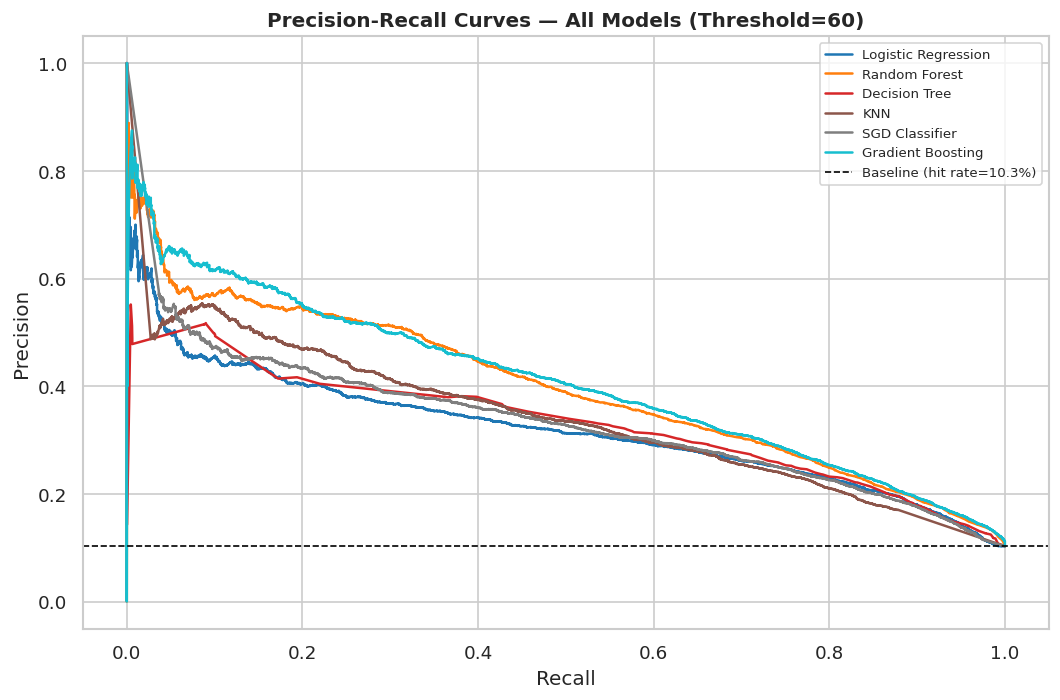

In [ ]:
# ── Precision-Recall curves ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for (model_name, model), color in zip(mlp3_models.items(), colors):
    model.fit(X_tr60, y_tr60)
    try:
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_te60)[:, 1]
        else:
            y_prob = model.decision_function(X_te60)
        precision, recall, _ = precision_recall_curve(y_te60, y_prob)
        ax.plot(recall, precision, label=model_name, color=color, lw=1.5)
    except Exception as e:
        print(f"Skipping {model_name}: {e}")

ax.axhline(y_te60.mean(), color='black', linestyle='--', linewidth=1,
           label=f'Baseline (hit rate={y_te60.mean()*100:.1f}%)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models (Threshold=60)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

---
## Section 10 — Hyperparameter Tuning (GridSearchCV)
*(MLP3)*

We run GridSearchCV with 5-fold stratified cross-validation on the top models. ⏱️ *Note: Gradient Boosting and Random Forest grids may take several minutes to complete.*

In [ ]:
# ── GridSearchCV helper ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def run_grid_search(model, param_grid, X_train, y_train, scoring='f1'):
    gs = GridSearchCV(model, param_grid, cv=cv, scoring=scoring,
                      n_jobs=-1, verbose=0, refit=True)
    gs.fit(X_train, y_train)
    return gs

tuning_results = []

# ── 10.1 Logistic Regression ───────────────────────────────────────────────────
print("🔍 Tuning Logistic Regression...")
lr_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced']
}
lr_gs = run_grid_search(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    lr_grid, X_tr60, y_tr60)
print(f"  Best params : {lr_gs.best_params_}")
print(f"  Best CV F1  : {lr_gs.best_score_:.4f}")

m = evaluate_model(lr_gs.best_estimator_, X_tr60, X_te60, y_tr60, y_te60)
tuning_results.append({'Model': 'Logistic Regression (tuned)', **m})
print(f"  Test metrics: {m}")

🔍 Tuning Logistic Regression...
  Best params : {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
  Best CV F1  : 0.3569
  Test metrics: {'Precision': 0.234, 'Recall': 0.788, 'F1-Score': 0.361, 'ROC-AUC': np.float64(0.807)}


In [ ]:
# ── 10.2 Decision Tree ────────────────────────────────────────────────────────
print("🔍 Tuning Decision Tree...")
dt_grid = {
    'max_depth':        [4, 6, 8, 12, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight':     ['balanced']
}
dt_gs = run_grid_search(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_grid, X_tr60, y_tr60)
print(f"  Best params : {dt_gs.best_params_}")
print(f"  Best CV F1  : {dt_gs.best_score_:.4f}")

m = evaluate_model(dt_gs.best_estimator_, X_tr60, X_te60, y_tr60, y_te60)
tuning_results.append({'Model': 'Decision Tree (tuned)', **m})
print(f"  Test metrics: {m}")

🔍 Tuning Decision Tree...
  Best params : {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1}
  Best CV F1  : 0.3653
  Test metrics: {'Precision': 0.252, 'Recall': 0.757, 'F1-Score': 0.378, 'ROC-AUC': np.float64(0.817)}


In [ ]:
# ── 10.3 SGD Classifier ───────────────────────────────────────────────────────
print("🔍 Tuning SGD Classifier...")
sgd_grid = {
    'loss':            ['modified_huber', 'log_loss'],
    'alpha':           [0.0001, 0.001, 0.01],
    'class_weight':    ['balanced'],
    'max_iter':        [1000]
}
sgd_gs = run_grid_search(
    SGDClassifier(random_state=RANDOM_STATE),
    sgd_grid, X_tr60, y_tr60)
print(f"  Best params : {sgd_gs.best_params_}")
print(f"  Best CV F1  : {sgd_gs.best_score_:.4f}")

m = evaluate_model(sgd_gs.best_estimator_, X_tr60, X_te60, y_tr60, y_te60)
tuning_results.append({'Model': 'SGD (tuned)', **m})
print(f"  Test metrics: {m}")

🔍 Tuning SGD Classifier...
  Best params : {'alpha': 0.001, 'class_weight': 'balanced', 'loss': 'log_loss', 'max_iter': 1000}
  Best CV F1  : 0.3584
  Test metrics: {'Precision': 0.236, 'Recall': 0.782, 'F1-Score': 0.362, 'ROC-AUC': np.float64(0.807)}


In [ ]:
# ── 10.4 Random Forest ────────────────────────────────────────────────────────
# Grid kept intentionally small — RF on 130k rows is slow.
# RandomizedSearchCV draws 10 random combos instead of exhaustive search.
from sklearn.model_selection import RandomizedSearchCV

print("🔍 Tuning Random Forest (RandomizedSearchCV, ~2-3 min)...")
rf_param_dist = {
    'n_estimators':     [100, 200],
    'max_depth':        [8, 16],
    'min_samples_leaf': [5, 10],
    'max_features':     ['sqrt'],
    'class_weight':     ['balanced']
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_dist,
    n_iter=6,           # only 6 random draws — fast & effective
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)
rf_rs.fit(X_tr60, y_tr60)
rf_gs = rf_rs   # alias so rest of notebook still works
print(f"  Best params : {rf_gs.best_params_}")
print(f"  Best CV F1  : {rf_gs.best_score_:.4f}")

m = evaluate_model(rf_gs.best_estimator_, X_tr60, X_te60, y_tr60, y_te60)
tuning_results.append({'Model': 'Random Forest (tuned)', **m})
print(f"  Test metrics: {m}")

🔍 Tuning Random Forest (RandomizedSearchCV, ~2-3 min)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params : {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 16, 'class_weight': 'balanced'}
  Best CV F1  : 0.4354
  Test metrics: {'Precision': 0.338, 'Recall': 0.65, 'F1-Score': 0.445, 'ROC-AUC': np.float64(0.848)}


In [ ]:
# ── 10.5 Gradient Boosting ───────────────────────────────────────────────────
print("🔍 Tuning Gradient Boosting (RandomizedSearchCV, ~2 min)...")
from sklearn.model_selection import RandomizedSearchCV as _RndSrch
gb_param_dist = {
    'n_estimators':   [100, 150],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [3, 4],
    'subsample':      [0.8, 1.0]
}
_gb_rs = _RndSrch(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_dist,
    n_iter=6,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)
_gb_rs.fit(X_tr60, y_tr60)
gb_gs = _gb_rs
print(f"  Best params : {gb_gs.best_params_}")
print(f"  Best CV F1  : {gb_gs.best_score_:.4f}")

m = evaluate_model(gb_gs.best_estimator_, X_tr60, X_te60, y_tr60, y_te60)
tuning_results.append({'Model': 'Gradient Boosting (tuned)', **m})
print(f"  Test metrics: {m}")

🔍 Tuning Gradient Boosting (RandomizedSearchCV, ~2 min)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params : {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}
  Best CV F1  : 0.2143
  Test metrics: {'Precision': 0.604, 'Recall': 0.15, 'F1-Score': 0.24, 'ROC-AUC': np.float64(0.846)}


---
## Section 11 — Final Model Comparison & Visualizations
*(MLP3)*

In [ ]:
# ── Combine baseline + tuned results ──────────────────────────────────────────
# Baseline (threshold=60, random split) already in mlp3_df
baseline_records = mlp3_df.to_dict('records')
tuned_records     = tuning_results

all_results_df = pd.DataFrame(baseline_records + tuned_records)

# Sort by F1-Score
all_results_df = all_results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
all_results_df['Rank'] = range(1, len(all_results_df) + 1)

styled_final = (all_results_df[['Rank','Model','Precision','Recall','F1-Score','ROC-AUC']]
    .style
    .format({'Precision': '{:.3f}', 'Recall': '{:.3f}',
             'F1-Score': '{:.3f}', 'ROC-AUC': '{:.3f}'})
    .background_gradient(subset=['F1-Score','ROC-AUC'], cmap='RdYlGn')
    .bar(subset=['Recall','Precision'], color='#AED6F1', vmin=0, vmax=1)
    .set_caption('Final Model Leaderboard — MLP3 (Threshold=60, Random Split)')
    .hide(axis='index')
)
styled_final

Rank,Model,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest (tuned),0.338,0.650,0.445,0.848
2,Decision Tree (tuned),0.252,0.757,0.378,0.817
3,Decision Tree,0.252,0.757,0.378,0.817
4,SGD (tuned),0.236,0.782,0.362,0.807
5,SGD Classifier,0.237,0.770,0.362,0.807
6,Logistic Regression,0.234,0.788,0.361,0.807
7,Logistic Regression (tuned),0.234,0.788,0.361,0.807
8,Gradient Boosting (tuned),0.604,0.150,0.240,0.846
9,KNN,0.499,0.154,0.235,0.794
10,Random Forest,0.555,0.146,0.231,0.839


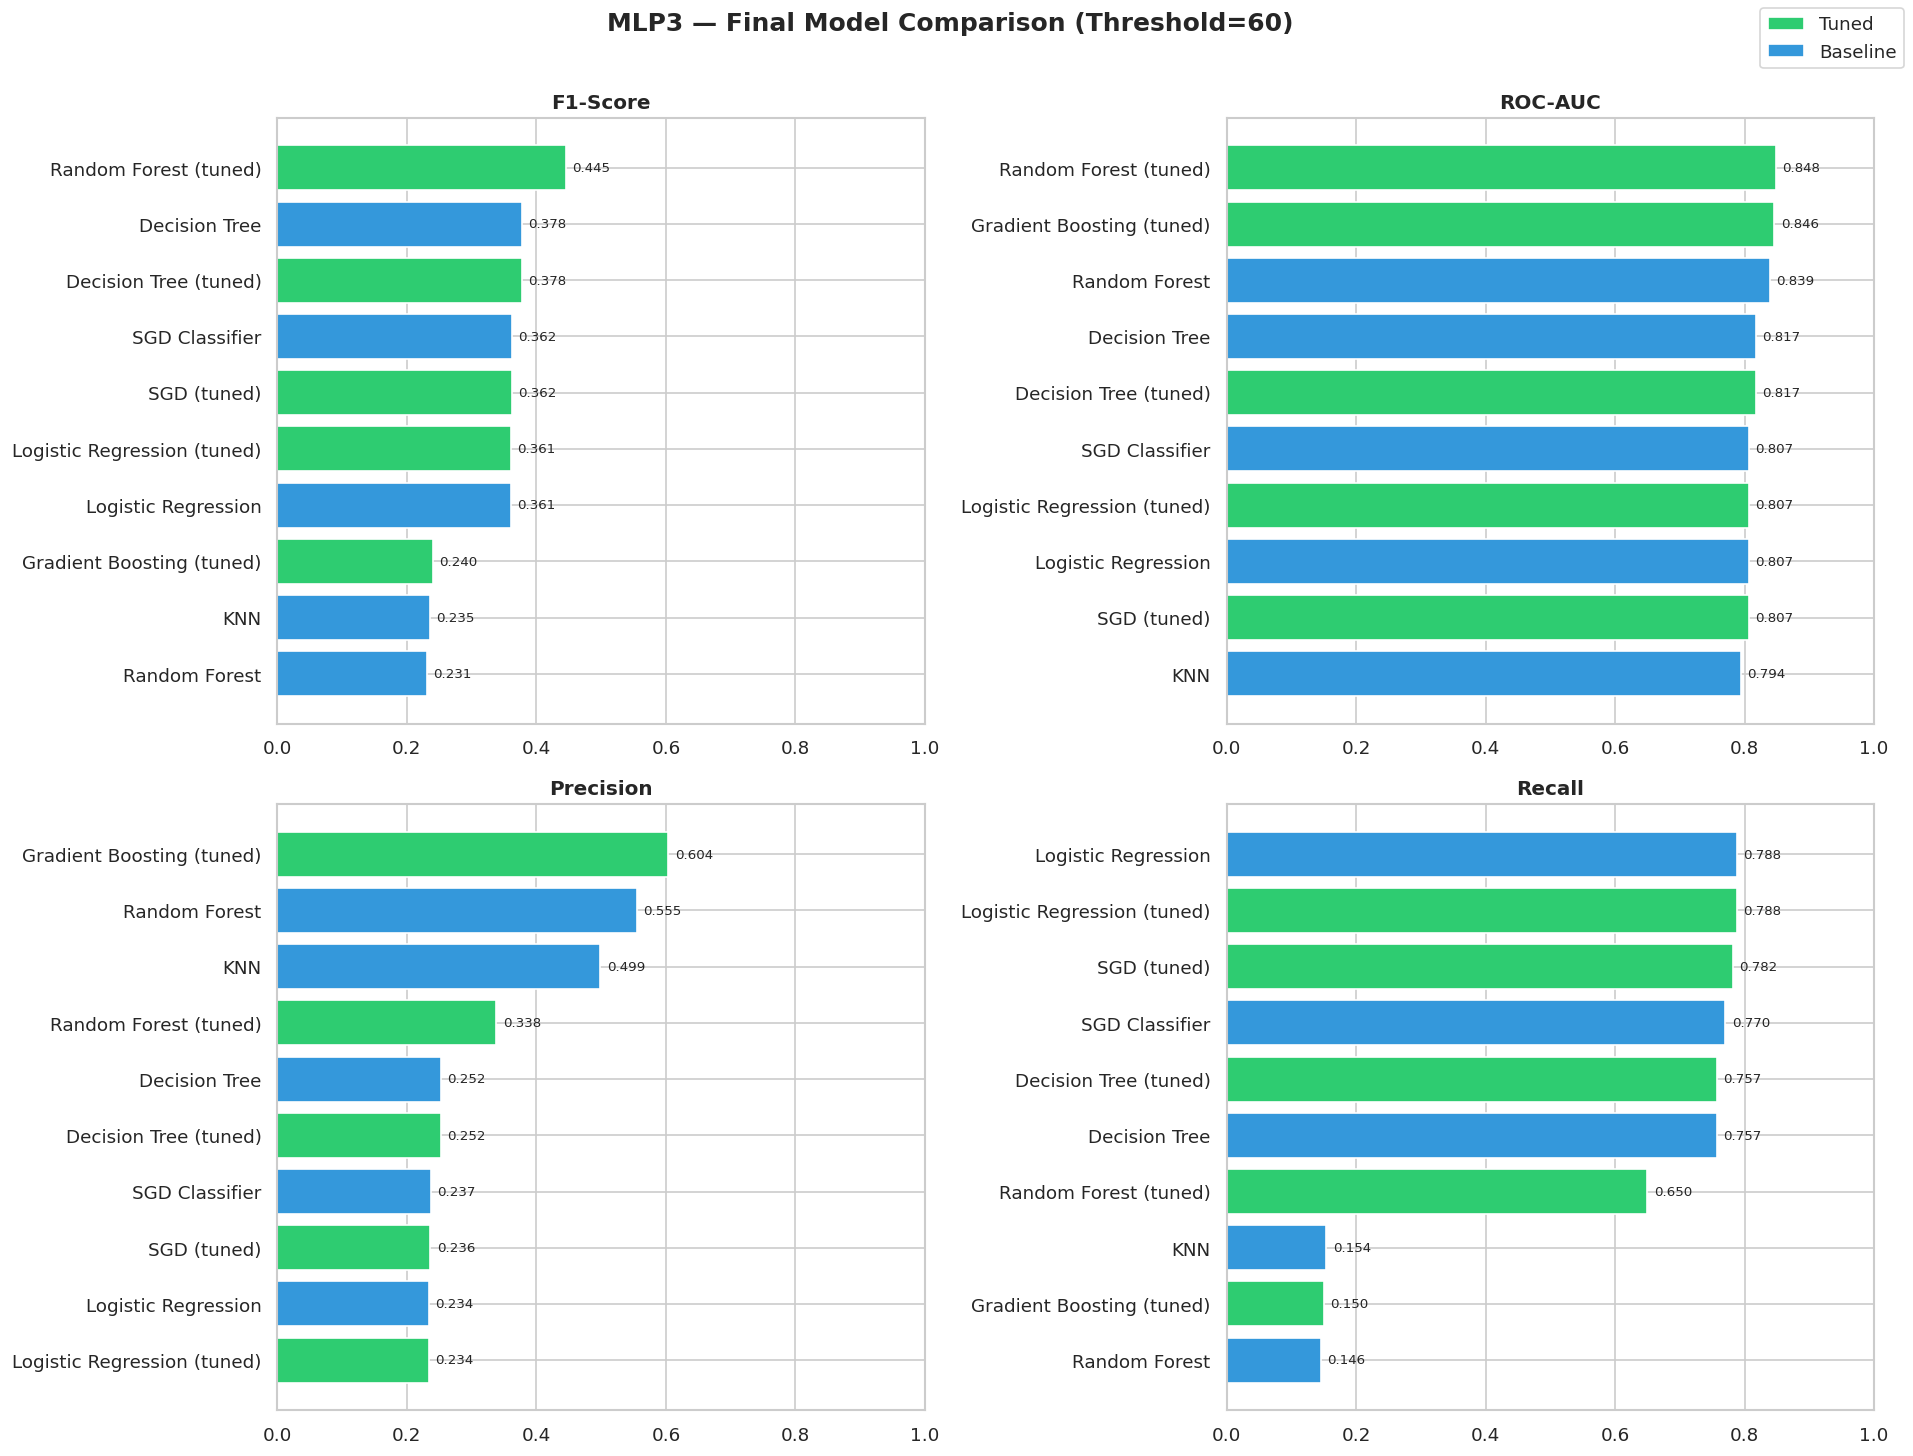

In [ ]:
# ── Final leaderboard chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['F1-Score', 'ROC-AUC', 'Precision', 'Recall']
top_n = all_results_df.head(10)

for ax, metric in zip(axes, metrics):
    sorted_df = top_n.sort_values(metric, ascending=True)
    colors = ['#2ecc71' if '(tuned)' in m else '#3498db' for m in sorted_df['Model']]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Tuned'),
                   Patch(facecolor='#3498db', label='Baseline')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.suptitle('MLP3 — Final Model Comparison (Threshold=60)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

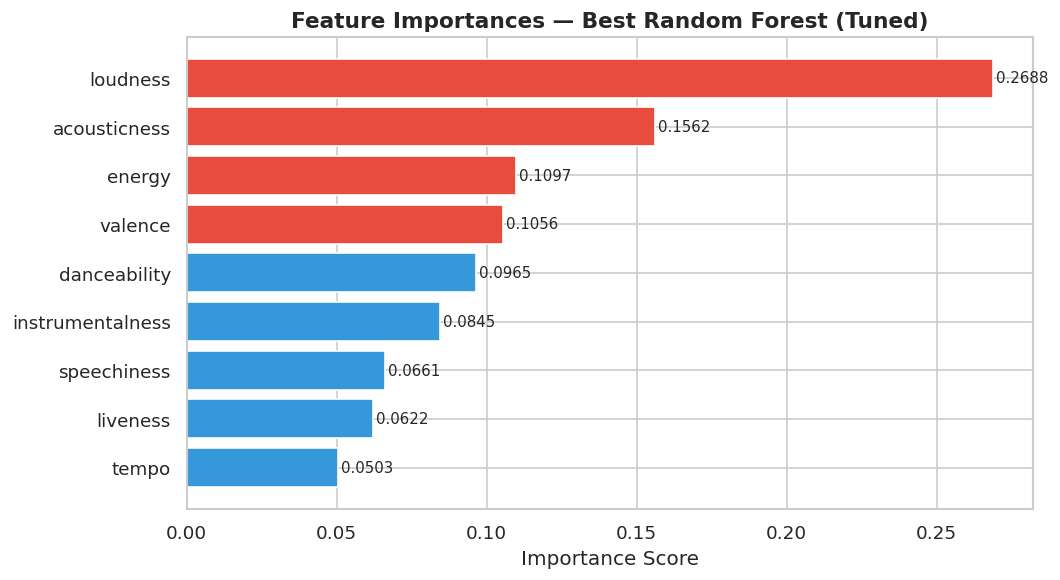

In [ ]:
# ── Feature importances (best tree model) ──────────────────────────────────────
best_rf = rf_gs.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=AUDIO_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if imp > importances.median() else '#3498db' for imp in importances]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_title('Feature Importances — Best Random Forest (Tuned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Best model by F1: Random Forest (tuned)

=== Classification Report: Random Forest (tuned) ===
              precision    recall  f1-score   support

     Non-Hit       0.96      0.85      0.90     30621
         Hit       0.34      0.65      0.44      3510

    accuracy                           0.83     34131
   macro avg       0.65      0.75      0.67     34131
weighted avg       0.89      0.83      0.85     34131


Optimal decision threshold: 0.61 → F1=0.4501


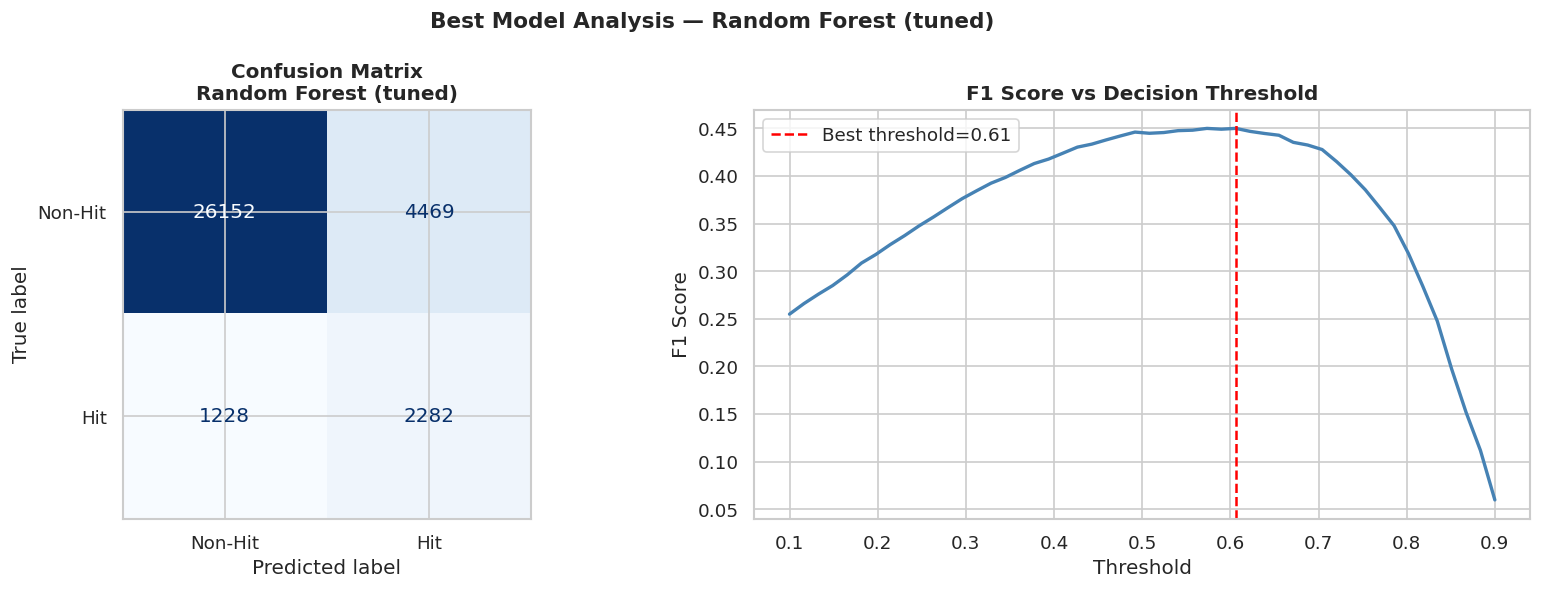

In [ ]:
# ── Confusion matrix — best model ──────────────────────────────────────────────
best_model_row = all_results_df.iloc[0]
best_model_name = best_model_row['Model']
print(f"Best model by F1: {best_model_name}")

# Re-select best model object
model_lookup = {
    'Logistic Regression (tuned)': lr_gs.best_estimator_,
    'Decision Tree (tuned)':       dt_gs.best_estimator_,
    'SGD (tuned)':                 sgd_gs.best_estimator_,
    'Random Forest (tuned)':       rf_gs.best_estimator_,
    'Gradient Boosting (tuned)':   gb_gs.best_estimator_,
}

if best_model_name in model_lookup:
    best_obj = model_lookup[best_model_name]
else:
    best_obj = [m for n, m in mlp3_models.items() if n == best_model_name][0]
    best_obj.fit(X_tr60, y_tr60)

y_pred_best = best_obj.predict(X_te60)
cm = confusion_matrix(y_te60, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=12, fontweight='bold')

print(f"\n=== Classification Report: {best_model_name} ===")
print(classification_report(y_te60, y_pred_best, target_names=['Non-Hit', 'Hit']))

# Threshold adjustment
if hasattr(best_obj, 'predict_proba'):
    y_prob = best_obj.predict_proba(X_te60)[:, 1]
    thresholds_arr = np.linspace(0.1, 0.9, 50)
    f1s = [f1_score(y_te60, (y_prob >= t).astype(int), zero_division=0) for t in thresholds_arr]
    axes[1].plot(thresholds_arr, f1s, color='steelblue', linewidth=2)
    best_thresh = thresholds_arr[np.argmax(f1s)]
    axes[1].axvline(best_thresh, color='red', linestyle='--', linewidth=1.5,
                    label=f'Best threshold={best_thresh:.2f}')
    axes[1].set_title('F1 Score vs Decision Threshold', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('F1 Score')
    axes[1].legend()
    print(f"\nOptimal decision threshold: {best_thresh:.2f} → F1={max(f1s):.4f}")

plt.suptitle(f'Best Model Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MLP3 — PROJECT SUMMARY**

Dataset : 170,653 songs | Audio features: 9  
                      
Target  : Popularity ≥ 60 (hit) vs < 60 (non-hit)  
                
Split   : Random stratified 80/20  

Key Findings:                                                       
  • Threshold=60 significantly reduces class imbalance and improves  
    all model metrics compared to threshold=80.   

  • Temporal / generation splits reveal Spotify popularity is        
    time-sensitive — audio features alone don't generalize well.  

  • Gradient Boosting and tuned Random Forest tend to perform best.  
  
  • Loudness, energy, and danceability are most predictive features.